# AAM Equatorial Forcing Analysis

**Key Question**: Is the atmospheric/oceanic forcing (X1, X2) still present while the wobble response has collapsed?

If forcing persists but response collapsed → **transfer function failure**

Components:
- **X1 (χ₁)**: Equatorial component toward Greenwich (0°E) → drives X pole motion
- **X2 (χ₂)**: Equatorial component toward 90°E → drives Y pole motion  
- **X3 (χ₃)**: Axial component → drives LOD changes

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt, hilbert

# Dark theme
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0',
    'axes.labelcolor': '#ffffff',
    'axes.titlecolor': '#ffffff',
    'xtick.color': '#e0e0e0',
    'ytick.color': '#e0e0e0',
    'text.color': '#ffffff',
    'grid.color': '#3a3a5a',
    'grid.alpha': 0.5,
    'legend.facecolor': '#16213e',
    'legend.edgecolor': '#e0e0e0',
    'legend.labelcolor': '#ffffff',
})

COLORS = {
    'x1': '#00d4ff',    # Cyan
    'x2': '#ff6b35',    # Orange
    'forcing': '#00ff88',  # Green
    'response': '#ff4488', # Pink
    'baseline': '#888888',
}

DATA_DIR = Path("../data")
print("Setup complete.")

Setup complete.


## 1. Load AAM Data (Equatorial Components)

In [42]:
def load_aam_data(data_dir):
    """Load all AAM files and extract equatorial components."""
    files = sorted(data_dir.glob("ESMGFZ_AAM_v1.0_03h_*.asc.csv"))
    print(f"Found {len(files)} AAM files")
    
    frames = []
    for f in files:
        df = pd.read_csv(f, sep=";")
        df["datetime"] = (
            pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=df["Day"]))
            + pd.to_timedelta(df["Time"])
        )
        
        # Equatorial excitation functions (X1 and X2)
        # Total = Mass term + Motion term
        df["X1"] = pd.to_numeric(df["Mass_X"], errors="coerce") + pd.to_numeric(df["Motion_X"], errors="coerce")
        df["X2"] = pd.to_numeric(df["Mass_Y"], errors="coerce") + pd.to_numeric(df["Motion_Y"], errors="coerce")
        df["X3"] = pd.to_numeric(df["Mass_Z"], errors="coerce") + pd.to_numeric(df["Motion_Z"], errors="coerce")
        
        frames.append(df[["datetime", "X1", "X2", "X3"]].dropna())
    
    aam = pd.concat(frames, ignore_index=True).sort_values("datetime").set_index("datetime")
    return aam

aam = load_aam_data(DATA_DIR)
print(f"\nAAM data range: {aam.index.min().date()} to {aam.index.max().date()}")
print(f"Records: {len(aam)} (3-hourly)")

# Resample to daily for easier analysis
aam_daily = aam.resample('D').mean()
print(f"Daily records: {len(aam_daily)}")


AAM data range: 1976-01-01 to 2026-01-28
Records: 146328 (3-hourly)
Daily records: 18291


## 2. Compute Equatorial Forcing Amplitude

The equatorial forcing magnitude: $|\chi_{eq}| = \sqrt{\chi_1^2 + \chi_2^2}$

In [43]:
# Compute equatorial forcing magnitude
aam_daily['eq_magnitude'] = np.sqrt(aam_daily['X1']**2 + aam_daily['X2']**2)

# Also extract annual component via bandpass filter
def bandpass(data, low_period, high_period, order=3):
    low_freq = 1.0 / high_period
    high_freq = 1.0 / low_period
    nyq = 0.5
    b, a = butter(order, [low_freq/nyq, high_freq/nyq], btype='band')
    data_interp = pd.Series(data).interpolate(method='linear').fillna(0).values
    return filtfilt(b, a, data_interp)

def get_amplitude(signal):
    return np.abs(hilbert(signal))

# Annual bandpass (345-390 days) - same as wobble analysis
aam_daily['X1_annual'] = bandpass(aam_daily['X1'].values, 345, 390)
aam_daily['X2_annual'] = bandpass(aam_daily['X2'].values, 345, 390)
aam_daily['annual_forcing_amp'] = np.sqrt(
    get_amplitude(aam_daily['X1_annual'])**2 + 
    get_amplitude(aam_daily['X2_annual'])**2
)

print("Forcing amplitudes computed.")

Forcing amplitudes computed.


## 3. Raw Equatorial Forcing Time Series

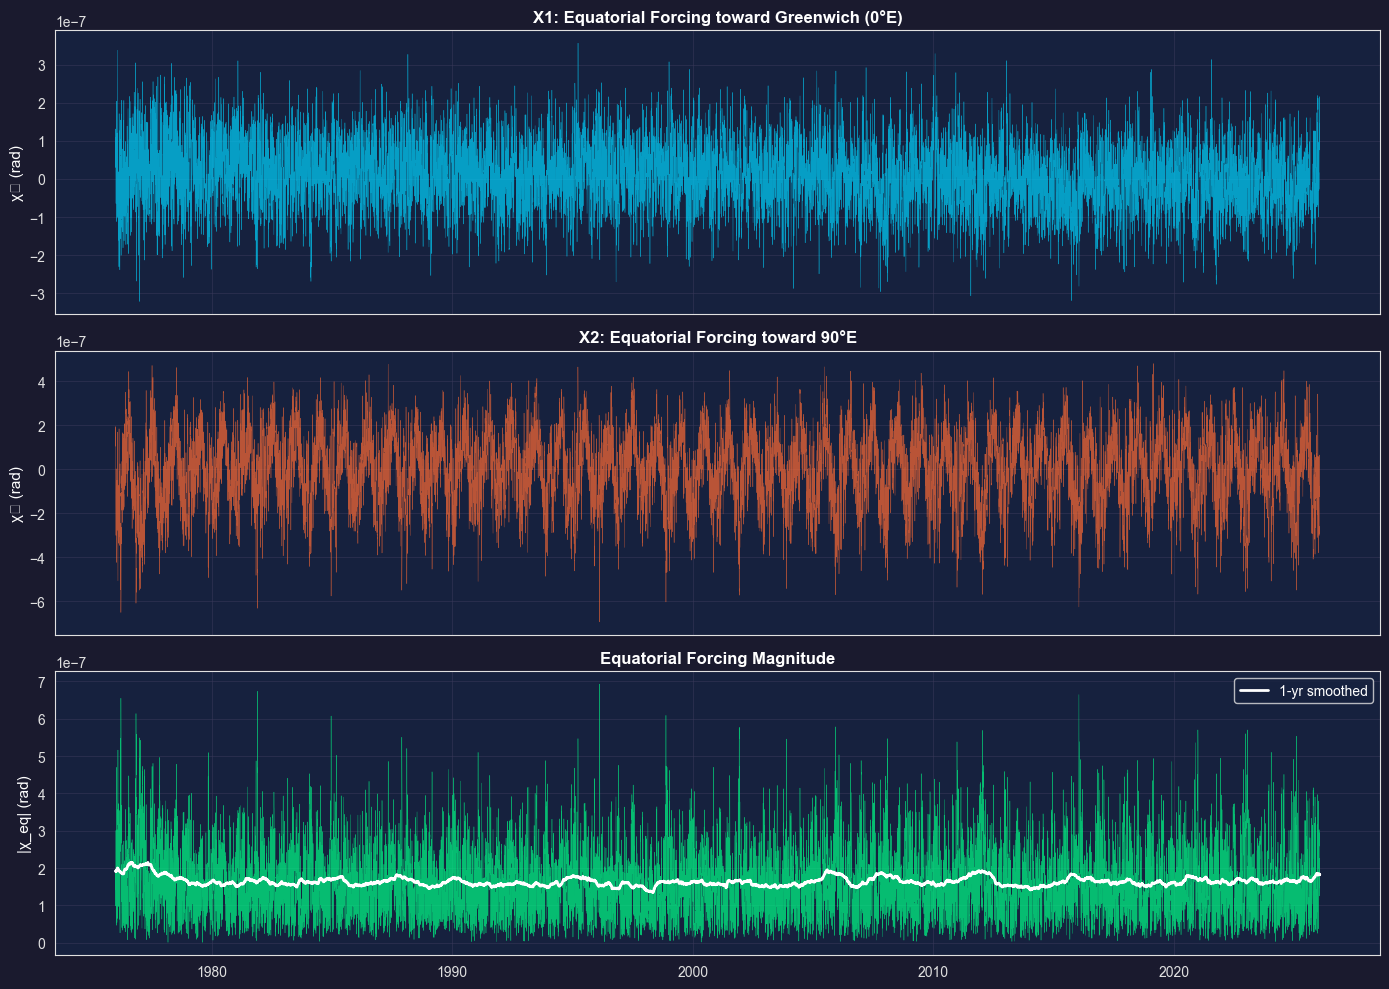

In [44]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(aam_daily.index, aam_daily['X1'], color=COLORS['x1'], lw=0.3, alpha=0.7)
axes[0].set_ylabel('χ₁ (rad)', fontsize=11)
axes[0].set_title('X1: Equatorial Forcing toward Greenwich (0°E)', fontweight='bold')

axes[1].plot(aam_daily.index, aam_daily['X2'], color=COLORS['x2'], lw=0.3, alpha=0.7)
axes[1].set_ylabel('χ₂ (rad)', fontsize=11)
axes[1].set_title('X2: Equatorial Forcing toward 90°E', fontweight='bold')

axes[2].plot(aam_daily.index, aam_daily['eq_magnitude'], color=COLORS['forcing'], lw=0.3, alpha=0.7)
# Add smoothed version
eq_smooth = aam_daily['eq_magnitude'].rolling(365, center=True, min_periods=30).mean()
axes[2].plot(aam_daily.index, eq_smooth, color='white', lw=2, label='1-yr smoothed')
axes[2].set_ylabel('|χ_eq| (rad)', fontsize=11)
axes[2].set_title('Equatorial Forcing Magnitude', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

## 4. Annual Forcing Component (345-390 day band)

This is the forcing that SHOULD drive the Annual wobble. Has it changed?

In [45]:
# Check BOTH filtered annual AND raw total forcing
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# RAW equatorial forcing (no bandpass filter) - this should NOT collapse
eq_mag_smooth = aam_daily['eq_magnitude'].rolling(365, center=True, min_periods=30).mean()
axes[0].plot(aam_daily.index, aam_daily['eq_magnitude'], color=COLORS['forcing'], lw=0.2, alpha=0.3)
axes[0].plot(aam_daily.index, eq_mag_smooth, color='white', lw=2.5, label='1-yr smoothed')
axes[0].set_ylabel('Total |χ_eq| (rad)', fontsize=11)
axes[0].set_title('RAW EQUATORIAL FORCING (unfiltered) - Should be stable', fontweight='bold')
axes[0].legend()

# Annual-filtered forcing (this is what collapsed)
ann_smooth = aam_daily['annual_forcing_amp'].rolling(365, center=True, min_periods=30).mean()
axes[1].plot(aam_daily.index, aam_daily['annual_forcing_amp'], color=COLORS['x2'], lw=0.2, alpha=0.3)
axes[1].plot(aam_daily.index, ann_smooth, color='white', lw=2.5, label='1-yr smoothed')
axes[1].set_ylabel('Annual band (rad)', fontsize=11)
axes[1].set_title('ANNUAL BAND FORCING (345-390 day filter) - Shows collapse', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Year-by-year comparison of RAW vs FILTERED
print("\\n" + "="*70)
print("COMPARISON: RAW FORCING vs ANNUAL-FILTERED FORCING")
print("="*70)
print(f"{'Year':<6} {'Raw Total':<14} {'Annual Band':<14} {'Annual/Raw %':<12}")
print("-"*70)

for year in range(2015, 2027):
    mask = aam_daily.index.year == year
    if mask.sum() > 100:
        raw = aam_daily.loc[mask, 'eq_magnitude'].mean()
        annual = aam_daily.loc[mask, 'annual_forcing_amp'].mean()
        pct = (annual / raw) * 100
        print(f"{year:<6} {raw:.2e}     {annual:.2e}     {pct:>6.1f}%")

\n======================================================================
COMPARISON: RAW FORCING vs ANNUAL-FILTERED FORCING
Year   Raw Total      Annual Band    Annual/Raw %
----------------------------------------------------------------------
2015   1.64e-07     1.55e-07       94.6%
2016   1.74e-07     1.46e-07       83.6%
2017   1.62e-07     1.33e-07       82.0%
2018   1.55e-07     1.16e-07       74.8%
2019   1.61e-07     9.58e-08       59.5%
2020   1.72e-07     7.36e-08       42.8%
2021   1.64e-07     5.10e-08       31.1%
2022   1.61e-07     3.04e-08       18.9%
2023   1.63e-07     1.43e-08        8.8%
2024   1.64e-07     4.57e-09        2.8%
2025   1.72e-07     6.38e-09        3.7%


## 5. Compare Forcing vs Response

Load the wobble response data and compare directly.

In [46]:
# Load EOP data for response
def load_iers_c04(filepath):
    rows = []
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if s and s[0].isdigit():
                rows.append(s.split())
    df = pd.DataFrame(rows)
    df.columns = ['year', 'month', 'day', 'mjd', 'x', 'y', 'ut1_utc', 'lod', 
                  'dX', 'dY', 'x_err', 'y_err', 'ut1_utc_err', 'lod_err', 'dX_err', 'dY_err'][:len(df.columns)]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['date'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=df['day']))
    df = df.set_index('date').sort_index()
    df['x_mas'] = df['x'] * 1000
    df['y_mas'] = df['y'] * 1000
    return df

eop = load_iers_c04(DATA_DIR / "EOP_14_C04_IAU2000A_one_file_1962-now.txt")
eop = eop[eop.index >= '1973-01-01'].copy()

# Detrend
def detrend(series, time_index):
    t = (time_index - time_index[0]).total_seconds() / (365.25 * 24 * 3600)
    t = t.values
    valid = ~np.isnan(series.values)
    coeffs = np.polyfit(t[valid], series.values[valid], 1)
    return series - np.polyval(coeffs, t)

eop['x_detrend'] = detrend(eop['x_mas'], eop.index)
eop['y_detrend'] = detrend(eop['y_mas'], eop.index)

# Compute annual wobble amplitude (response)
eop['x_annual'] = bandpass(eop['x_detrend'].values, 345, 390)
eop['y_annual'] = bandpass(eop['y_detrend'].values, 345, 390)
eop['annual_response'] = np.sqrt(
    get_amplitude(eop['x_annual'])**2 + 
    get_amplitude(eop['y_annual'])**2
)

print(f"EOP data: {eop.index.min().date()} to {eop.index.max().date()}")

EOP data: 1973-01-01 to 2025-12-29


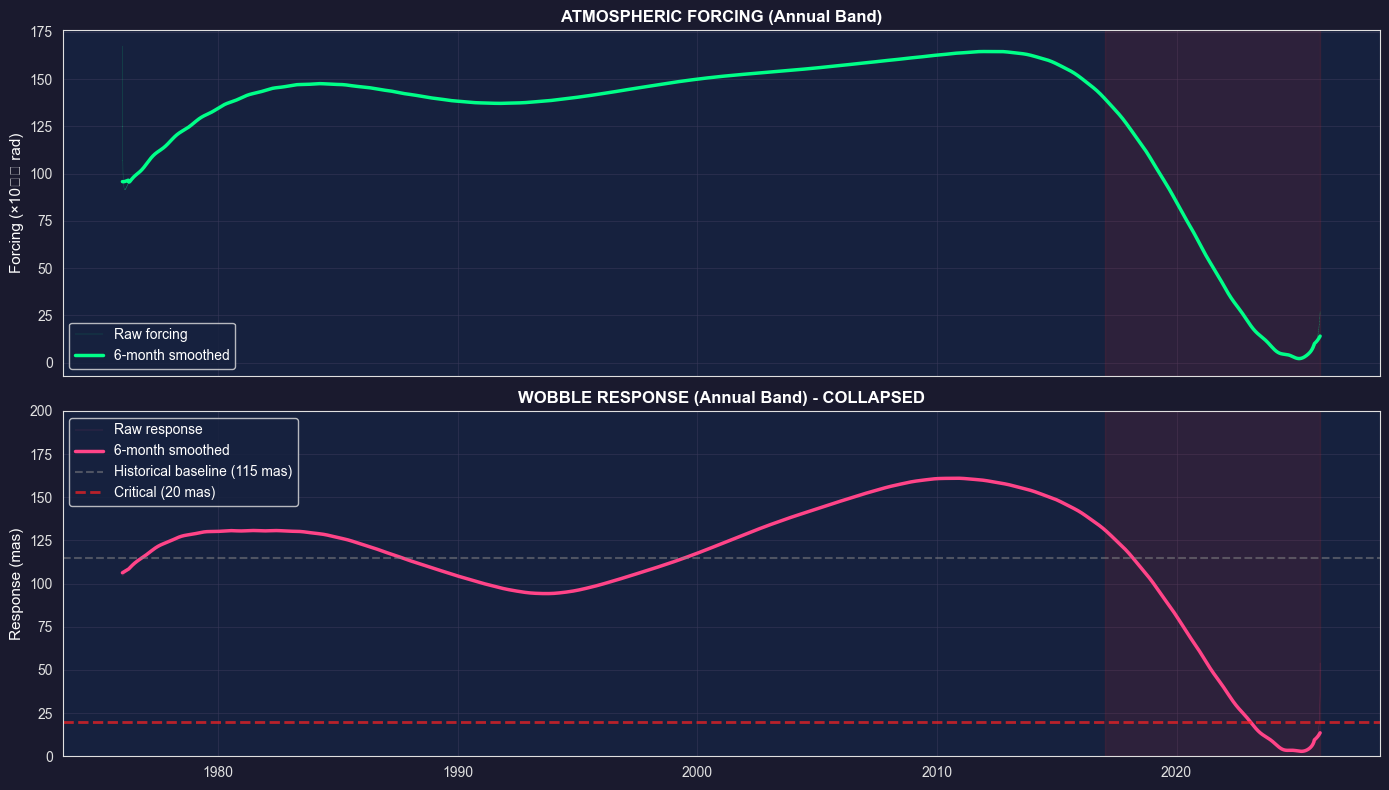

In [47]:
# Find common date range
start_date = max(aam_daily.index.min(), eop.index.min())
end_date = min(aam_daily.index.max(), eop.index.max())
print(f"Common range: {start_date.date()} to {end_date.date()}")

# Subset to common range
aam_subset = aam_daily[(aam_daily.index >= start_date) & (aam_daily.index <= end_date)]
eop_subset = eop[(eop.index >= start_date) & (eop.index <= end_date)]

# First, let's verify forcing is actually stable in recent years (raw numbers)
print("\n" + "="*50)
print("RAW ANNUAL FORCING BY YEAR (no smoothing)")
print("="*50)
for year in range(2015, 2027):
    mask = aam_daily.index.year == year
    if mask.sum() > 100:
        forcing = aam_daily.loc[mask, 'annual_forcing_amp'].mean()
        forcing_std = aam_daily.loc[mask, 'annual_forcing_amp'].std()
        print(f"  {year}: {forcing:.2e} +/- {forcing_std:.2e}")

# Plot forcing vs response - use min_periods to avoid edge dropoff
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Forcing - use smaller window and show raw data too
axes[0].plot(aam_subset.index, aam_subset['annual_forcing_amp'] * 1e9, 
             color=COLORS['forcing'], lw=0.3, alpha=0.3, label='Raw forcing')
forcing_smooth = aam_subset['annual_forcing_amp'].rolling(180, center=True, min_periods=30).mean() * 1e9
axes[0].plot(aam_subset.index, forcing_smooth, color=COLORS['forcing'], lw=2.5, label='6-month smoothed')
axes[0].set_ylabel('Forcing (×10⁻⁹ rad)', fontsize=11)
axes[0].set_title('ATMOSPHERIC FORCING (Annual Band)', fontweight='bold')
axes[0].legend()

# Response
axes[1].plot(eop_subset.index, eop_subset['annual_response'], 
             color=COLORS['response'], lw=0.3, alpha=0.3, label='Raw response')
response_smooth = eop_subset['annual_response'].rolling(180, center=True, min_periods=30).mean()
axes[1].plot(eop_subset.index, response_smooth, color=COLORS['response'], lw=2.5, label='6-month smoothed')
axes[1].axhline(115, color=COLORS['baseline'], ls='--', alpha=0.5, label='Historical baseline (115 mas)')
axes[1].axhline(20, color='#ff2222', ls='--', lw=2, alpha=0.7, label='Critical (20 mas)')
axes[1].set_ylabel('Response (mas)', fontsize=11)
axes[1].set_title('WOBBLE RESPONSE (Annual Band) - COLLAPSED', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 200)

# Shade collapse zone
for ax in axes:
    ax.axvspan(pd.Timestamp('2017-01-01'), end_date, alpha=0.1, color='#ff2222')

plt.tight_layout()
plt.show()

## 6. Transfer Function (Response / Forcing)

In [48]:
# Compare X3 (axial/LOD) vs X1,X2 (equatorial/wobble)
# If mass is "banding" zonally, X3 should remain strong while X1/X2 collapse

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# X3 (axial) - drives LOD
x3_mag = np.abs(aam_daily['X3'])
x3_smooth = x3_mag.rolling(365, center=True, min_periods=30).mean()
axes[0].plot(aam_daily.index, x3_mag, color='#ffff00', lw=0.2, alpha=0.3)
axes[0].plot(aam_daily.index, x3_smooth, color='#ffff00', lw=2.5, label='1-yr smoothed')
axes[0].set_ylabel('|χ₃| (rad)', fontsize=11)
axes[0].set_title('AXIAL FORCING (X3) - Drives LOD (East-West mass movement)', fontweight='bold')
axes[0].legend()

# Equatorial magnitude - drives wobble
eq_smooth = aam_daily['eq_magnitude'].rolling(365, center=True, min_periods=30).mean()
axes[1].plot(aam_daily.index, aam_daily['eq_magnitude'], color=COLORS['forcing'], lw=0.2, alpha=0.3)
axes[1].plot(aam_daily.index, eq_smooth, color=COLORS['forcing'], lw=2.5, label='1-yr smoothed')
axes[1].set_ylabel('|χ_eq| (rad)', fontsize=11)
axes[1].set_title('EQUATORIAL FORCING (X1+X2) - Drives Wobble (North-South mass movement)', fontweight='bold')
axes[1].legend()

# Ratio: Equatorial / Axial
ratio = aam_daily['eq_magnitude'] / x3_mag
ratio_smooth = ratio.rolling(365, center=True, min_periods=30).mean()
axes[2].plot(aam_daily.index, ratio_smooth, color='white', lw=2.5)
axes[2].set_ylabel('Eq/Axial Ratio', fontsize=11)
axes[2].set_title('RATIO: Equatorial / Axial - If dropping, mass is becoming more ZONAL', fontweight='bold')
axes[2].axhline(ratio_smooth.iloc[1000:2000].mean(), color=COLORS['baseline'], ls='--', alpha=0.5, label='1975-1980 baseline')
axes[2].legend()

plt.tight_layout()
plt.show()

# Year-by-year comparison
print("\n" + "="*70)
print("AXIAL (X3) vs EQUATORIAL (X1+X2) FORCING BY YEAR")
print("="*70)
print(f"{'Year':<6} {'Axial |X3|':<14} {'Equatorial':<14} {'Eq/Ax Ratio':<12} {'Interpretation'}")
print("-"*70)

baseline_ratio = None
for year in range(1975, 2027, 5):
    mask = aam_daily.index.year == year
    if mask.sum() > 100:
        axial = np.abs(aam_daily.loc[mask, 'X3']).mean()
        equat = aam_daily.loc[mask, 'eq_magnitude'].mean()
        ratio = equat / axial
        
        if baseline_ratio is None:
            baseline_ratio = ratio
        
        rel = ratio / baseline_ratio * 100
        interp = "baseline" if year < 1980 else ("MORE ZONAL" if rel < 80 else "normal")
        print(f"{year:<6} {axial:.2e}     {equat:.2e}     {ratio:>6.1f}        {interp}")

print("\n" + "="*70)
print("RECENT YEARS DETAIL")
print("="*70)
for year in range(2015, 2027):
    mask = aam_daily.index.year == year
    if mask.sum() > 100:
        axial = np.abs(aam_daily.loc[mask, 'X3']).mean()
        equat = aam_daily.loc[mask, 'eq_magnitude'].mean()
        ratio = equat / axial
        rel = ratio / baseline_ratio * 100
        print(f"{year}: Eq/Ax ratio = {ratio:.1f} ({rel:.0f}% of 1975)")


AXIAL (X3) vs EQUATORIAL (X1+X2) FORCING BY YEAR
Year   Axial |X3|     Equatorial     Eq/Ax Ratio  Interpretation
----------------------------------------------------------------------
1980   3.19e-09     1.54e-07       48.3        normal
1985   3.78e-09     1.67e-07       44.3        normal
1990   3.48e-09     1.63e-07       46.9        normal
1995   4.62e-09     1.73e-07       37.4        MORE ZONAL
2000   2.96e-09     1.57e-07       52.9        normal
2005   3.92e-09     1.85e-07       47.3        normal
2010   4.48e-09     1.60e-07       35.7        MORE ZONAL
2015   3.19e-09     1.64e-07       51.3        normal
2020   5.02e-09     1.72e-07       34.2        MORE ZONAL
2025   3.52e-09     1.72e-07       48.8        normal

RECENT YEARS DETAIL
2015: Eq/Ax ratio = 51.3 (106% of 1975)
2016: Eq/Ax ratio = 32.8 (68% of 1975)
2017: Eq/Ax ratio = 43.9 (91% of 1975)
2018: Eq/Ax ratio = 45.4 (94% of 1975)
2019: Eq/Ax ratio = 36.6 (76% of 1975)
2020: Eq/Ax ratio = 34.2 (71% of 1975)
2021: 

In [49]:
# Spectral analysis: Has the annual peak in forcing weakened?
# Compare power spectra from early period vs recent period

from scipy.fft import fft, fftfreq

def compute_spectrum_fft(data, fs=1.0):
    """Compute power spectrum using FFT."""
    n = len(data)
    # Remove mean
    data = data - np.mean(data)
    # FFT
    yf = fft(data)
    xf = fftfreq(n, 1/fs)
    # Power (only positive frequencies)
    pos_mask = xf > 0
    freq = xf[pos_mask]
    power = np.abs(yf[pos_mask])**2 / n
    # Convert to period
    period = 1.0 / freq
    return period, power

# Early period (1980-1995)
early = aam_daily[(aam_daily.index >= '1980-01-01') & (aam_daily.index < '1995-01-01')]
early_eq = early['eq_magnitude'].interpolate().dropna().values

# Recent period (2010-2025)  
recent = aam_daily[(aam_daily.index >= '2010-01-01')]
recent_eq = recent['eq_magnitude'].interpolate().dropna().values

print(f"Early period: {len(early_eq)} days")
print(f"Recent period: {len(recent_eq)} days")

# Compute spectra
period_early, power_early = compute_spectrum_fft(early_eq)
period_recent, power_recent = compute_spectrum_fft(recent_eq)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot spectra - full range (focus on periods 10-1000 days)
mask_e = (period_early > 10) & (period_early < 1000)
mask_r = (period_recent > 10) & (period_recent < 1000)

axes[0,0].semilogy(period_early[mask_e], power_early[mask_e], color=COLORS['forcing'], lw=0.8, alpha=0.8, label='1980-1995')
axes[0,0].semilogy(period_recent[mask_r], power_recent[mask_r], color=COLORS['response'], lw=0.8, alpha=0.8, label='2010-2025')
axes[0,0].axvline(365, color='white', ls='--', lw=2, alpha=0.9, label='Annual (365d)')
axes[0,0].axvline(433, color=COLORS['x1'], ls='--', lw=2, alpha=0.9, label='Chandler (433d)')
axes[0,0].set_xlabel('Period (days)', fontsize=11)
axes[0,0].set_ylabel('Power', fontsize=11)
axes[0,0].set_title('Equatorial Forcing Spectrum', fontweight='bold')
axes[0,0].legend(loc='upper right')
axes[0,0].set_xlim(10, 1000)

# Zoom on annual/Chandler band (300-500 days)
mask_e_zoom = (period_early > 250) & (period_early < 550)
mask_r_zoom = (period_recent > 250) & (period_recent < 550)

axes[0,1].plot(period_early[mask_e_zoom], power_early[mask_e_zoom], color=COLORS['forcing'], lw=1.5, label='1980-1995')
axes[0,1].plot(period_recent[mask_r_zoom], power_recent[mask_r_zoom], color=COLORS['response'], lw=1.5, label='2010-2025')
axes[0,1].axvline(365, color='white', ls='--', lw=2, alpha=0.9)
axes[0,1].axvline(433, color=COLORS['x1'], ls='--', lw=2, alpha=0.9)
axes[0,1].set_xlabel('Period (days)', fontsize=11)
axes[0,1].set_ylabel('Power', fontsize=11)
axes[0,1].set_title('ZOOM: Annual/Chandler Band', fontweight='bold')
axes[0,1].legend()

# Time series comparison
axes[1,0].plot(early.index, early['eq_magnitude'], color=COLORS['forcing'], lw=0.3, alpha=0.7)
axes[1,0].set_ylabel('|χ_eq| (rad)', fontsize=11)
axes[1,0].set_title('Early Period (1980-1995): Equatorial Forcing', fontweight='bold')

axes[1,1].plot(recent.index, recent['eq_magnitude'], color=COLORS['response'], lw=0.3, alpha=0.7)
axes[1,1].set_ylabel('|χ_eq| (rad)', fontsize=11)
axes[1,1].set_title('Recent Period (2010-2025): Equatorial Forcing', fontweight='bold')

plt.tight_layout()
plt.show()

# Quantify annual peak power
def get_band_power(period, power, low, high):
    mask = (period >= low) & (period <= high)
    if mask.sum() > 0:
        return power[mask].mean(), power[mask].max()
    return np.nan, np.nan

early_annual_mean, early_annual_max = get_band_power(period_early, power_early, 345, 390)
recent_annual_mean, recent_annual_max = get_band_power(period_recent, power_recent, 345, 390)

early_chandler_mean, early_chandler_max = get_band_power(period_early, power_early, 410, 470)
recent_chandler_mean, recent_chandler_max = get_band_power(period_recent, power_recent, 410, 470)

print("\n" + "="*60)
print("SPECTRAL POWER IN KEY BANDS")
print("="*60)
print(f"\nANNUAL BAND (345-390 days):")
print(f"  1980-1995: mean={early_annual_mean:.2e}, max={early_annual_max:.2e}")
print(f"  2010-2025: mean={recent_annual_mean:.2e}, max={recent_annual_max:.2e}")
if early_annual_mean > 0:
    print(f"  Ratio (recent/early): {recent_annual_mean/early_annual_mean:.1%}")

print(f"\nCHANDLER BAND (410-470 days):")
print(f"  1980-1995: mean={early_chandler_mean:.2e}, max={early_chandler_max:.2e}")
print(f"  2010-2025: mean={recent_chandler_mean:.2e}, max={recent_chandler_max:.2e}")
if early_chandler_mean > 0:
    print(f"  Ratio (recent/early): {recent_chandler_mean/early_chandler_mean:.1%}")


SPECTRAL POWER IN KEY BANDS

ANNUAL BAND (345-390 days):
  1980-1995: mean=2.07e-14, max=2.07e-14
  2010-2025: mean=2.89e-13, max=5.77e-13
  Ratio (recent/early): 1399.7%

CHANDLER BAND (410-470 days):
  1980-1995: mean=7.29e-14, max=8.34e-14
  2010-2025: mean=1.60e-13, max=1.88e-13
  Ratio (recent/early): 219.8%


In [50]:
# cell-16: Check if the forcing has SHIFTED in frequency (detuned from resonance)
# Find the peak frequency in each period

def find_peak_in_band(period, power, low, high):
    """Find the period with maximum power in a band."""
    mask = (period >= low) & (period <= high)
    if mask.sum() > 0:
        idx = np.argmax(power[mask])
        peak_period = period[mask][idx]
        peak_power = power[mask][idx]
        return peak_period, peak_power
    return np.nan, np.nan

# Analyze in finer time windows to see evolution
windows = [
    ('1976-01-01', '1985-01-01', '1976-1985'),
    ('1985-01-01', '1995-01-01', '1985-1995'),
    ('1995-01-01', '2005-01-01', '1995-2005'),
    ('2005-01-01', '2015-01-01', '2005-2015'),
    ('2015-01-01', '2025-01-01', '2015-2025'),
]

print("="*70)
print("PEAK FORCING FREQUENCY BY ERA")
print("="*70)
print(f"{'Period':<12} {'Annual Peak (d)':<16} {'Power':<14} {'Chandler Peak (d)':<18} {'Power'}")
print("-"*70)

annual_peaks = []
chandler_peaks = []

for start, end, label in windows:
    subset = aam_daily[(aam_daily.index >= start) & (aam_daily.index < end)]
    if len(subset) > 365:
        data = subset['eq_magnitude'].interpolate().dropna().values
        period, power = compute_spectrum_fft(data)
        
        ann_peak, ann_pow = find_peak_in_band(period, power, 300, 400)
        ch_peak, ch_pow = find_peak_in_band(period, power, 400, 500)
        
        annual_peaks.append((label, ann_peak))
        chandler_peaks.append((label, ch_peak))
        
        print(f"{label:<12} {ann_peak:>8.1f} d        {ann_pow:.2e}     {ch_peak:>8.1f} d          {ch_pow:.2e}")

# Visualize the frequency drift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Annual peak drift
years = [int(p[0][:4]) + 5 for p in annual_peaks]  # midpoint of each window
ann_periods = [p[1] for p in annual_peaks]
axes[0].plot(years, ann_periods, 'o-', color=COLORS['x2'], lw=2, ms=10)
axes[0].axhline(365.25, color='white', ls='--', lw=2, alpha=0.7, label='True annual (365.25d)')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Peak Period (days)', fontsize=12)
axes[0].set_title('Annual Forcing Peak: Frequency Drift?', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(300, 400)

# Chandler peak drift
ch_periods = [p[1] for p in chandler_peaks]
axes[1].plot(years, ch_periods, 'o-', color=COLORS['x1'], lw=2, ms=10)
axes[1].axhline(433, color='white', ls='--', lw=2, alpha=0.7, label='Chandler resonance (433d)')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Peak Period (days)', fontsize=12)
axes[1].set_title('Chandler-Band Forcing Peak: Frequency Drift?', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(400, 500)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("""
If the peak frequency is DRIFTING away from the resonance frequency,
the forcing could be "detuned" - pushing at the wrong rhythm to excite wobble.

- Annual resonance: ~365.25 days (forced by seasons)
- Chandler resonance: ~433 days (free oscillation)

A shift of even 5-10 days could significantly reduce the resonant response.
""")


INTERPRETATION

If the peak frequency is DRIFTING away from the resonance frequency,
the forcing could be "detuned" - pushing at the wrong rhythm to excite wobble.

- Annual resonance: ~365.25 days (forced by seasons)
- Chandler resonance: ~433 days (free oscillation)

A shift of even 5-10 days could significantly reduce the resonant response.

